<a href="https://colab.research.google.com/github/2406047FajarA/TB-PrakBasdat-B-Kelompok6/blob/main/Prediksi_Penyakit_Tanaman_Menggunakan_Algoritma_Decision_Tree_dan_Random_Forest_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Semua library berhasil diimport!
Pandas version: 2.2.2
Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package
License(s): other
100% 3.83M/3.83M [00:00<00:00, 223MB/s]

Dataset berhasil dimuat!
Jumlah data: 145460
Jumlah fitur: 23

5 Data Pertama:

=== DATA UNDERSTANDING ===

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     14123

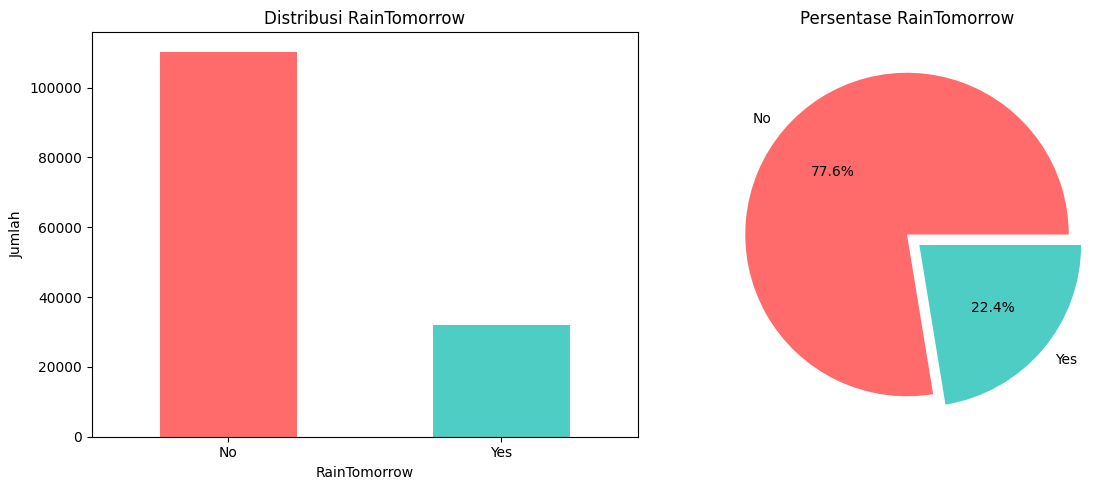

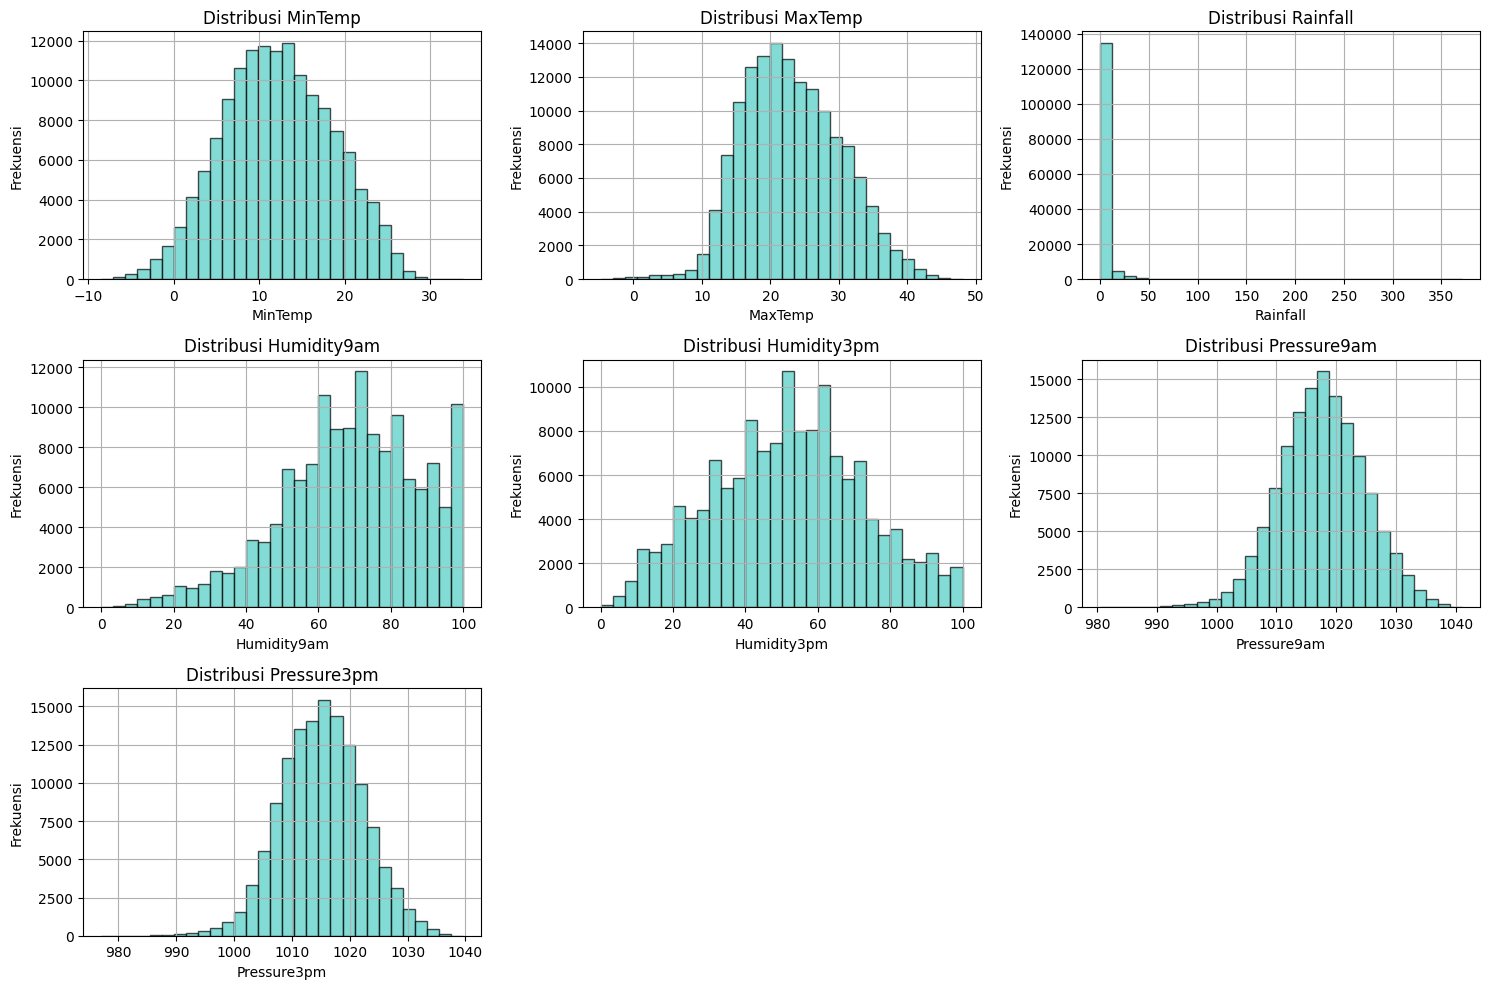

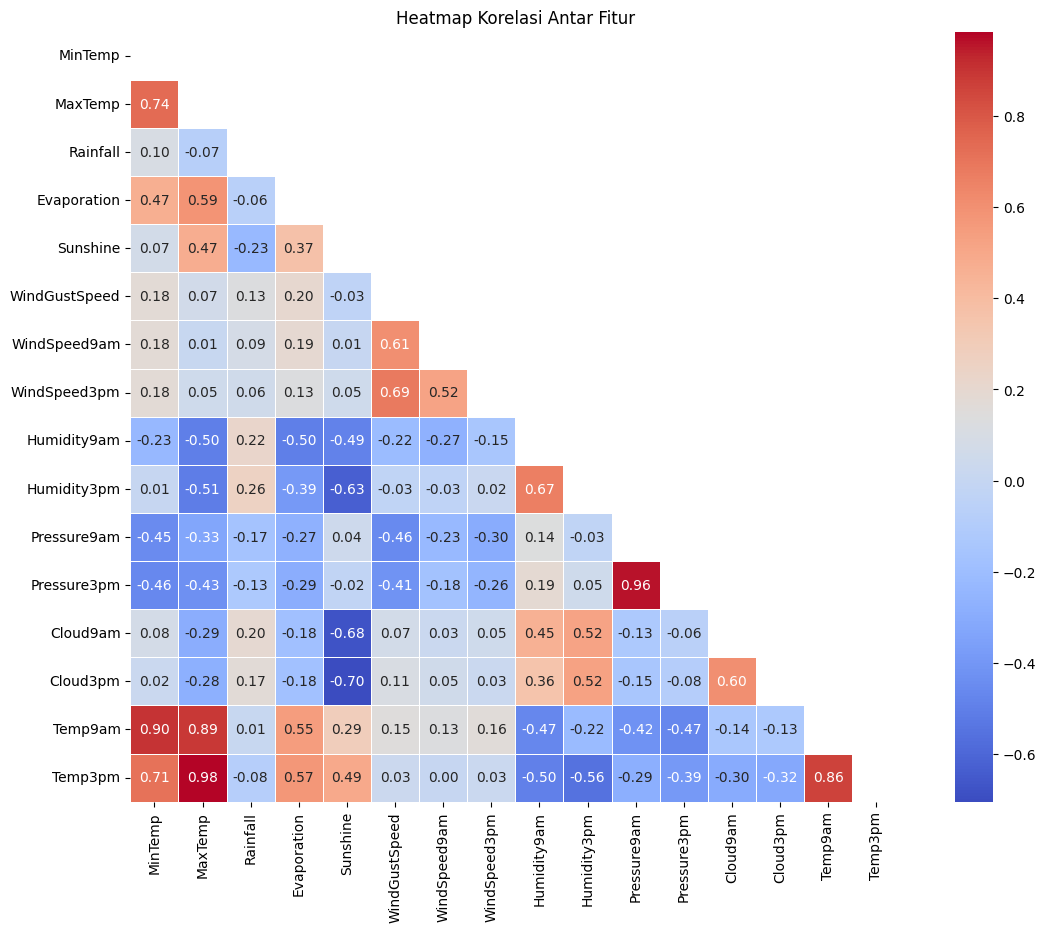

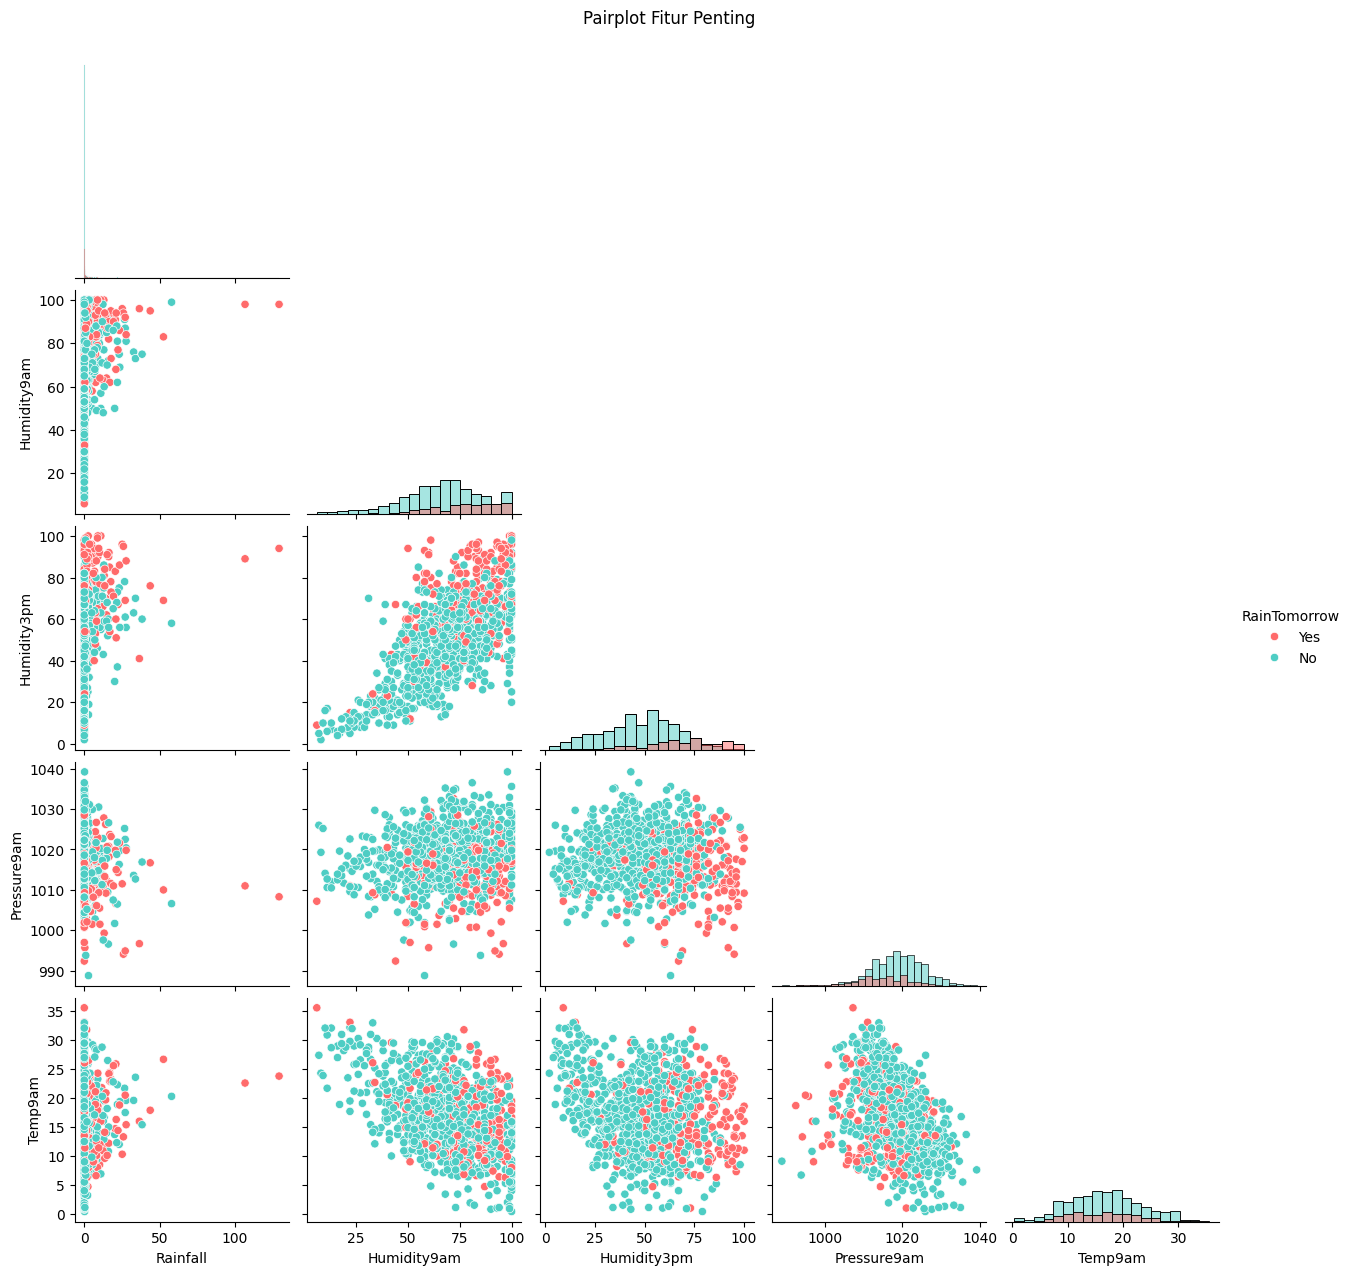

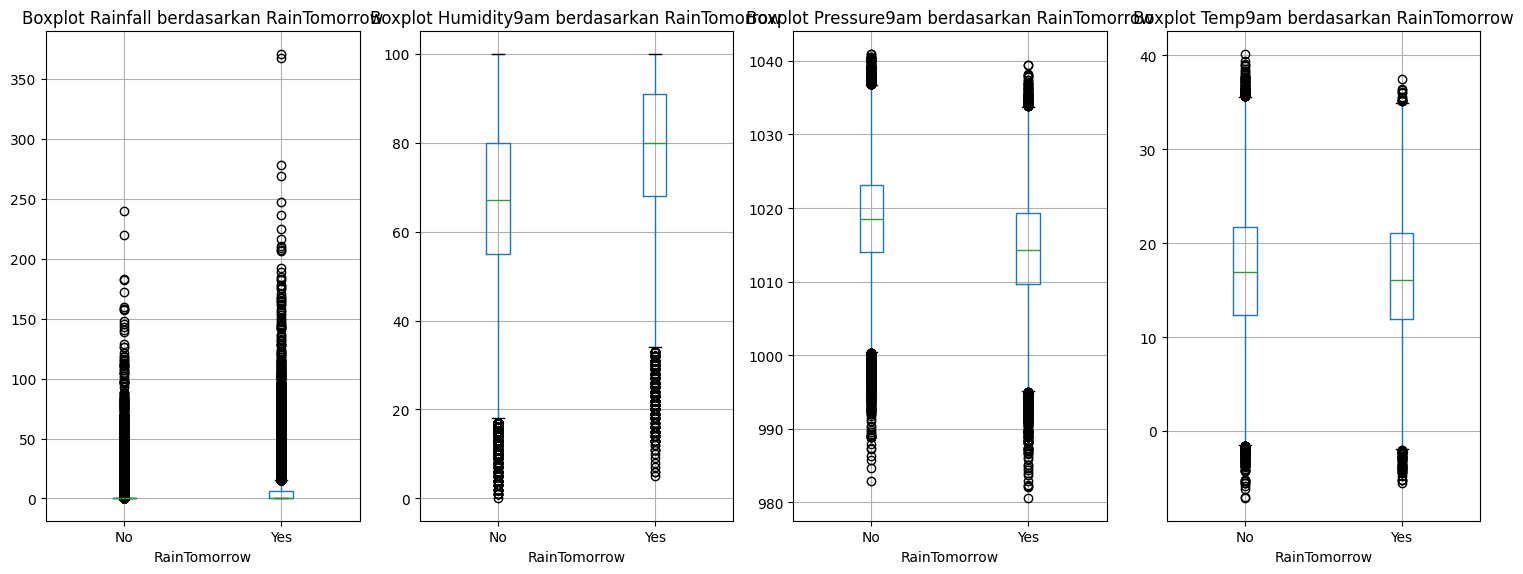


=== DATA PREPARATION ===
Jumlah missing values setelah ditangani: 0
X_train shape: (116368, 20)
X_test shape: (29092, 20)
y_train distribution: {0.0: 90866, 1.0: 25502}
y_test distribution: {0.0: 22717, 1.0: 6375}

=== MODELING ===

--- Decision Tree ---
Decision Tree Accuracy: 0.8405
Decision Tree Cross Validation Mean: 0.8388 (+/- 0.0019)

--- K-Nearest Neighbor ---


In [ ]:
# ========================================
# PROYEK UAS KECERDASAN BUATAN
# PREDIKSI CURAH HUJAN
# FAJAR ALAMSYAH - 2406047
# TYAS HAKIM A - 2406059
# ========================================

# ========================================
# SECTION 1: INSTALLASI DAN IMPORT LIBRARY
# ========================================

!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")
print(f"Pandas version: {pd.__version__}")

# ========================================
# SECTION 2: LOAD DATASET
# ========================================

# Download dataset dari Kaggle (Weather Dataset)
!kaggle datasets download -d jsphyg/weather-dataset-rattle-package
!unzip -q weather-dataset-rattle-package.zip

# Load dataset
df = pd.read_csv('weatherAUS.csv')

print("Dataset berhasil dimuat!")
print(f"Jumlah data: {len(df)}")
print(f"Jumlah fitur: {len(df.columns)}")

# Tampilkan 5 data pertama
print("\n5 Data Pertama:")
df.head()

# ========================================
# SECTION 3: DATA UNDERSTANDING
# ========================================

print("\n=== DATA UNDERSTANDING ===")

# Info dataset
print("\nInformasi Dataset:")
df.info()

# Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()

# Cek missing values
print("\nMissing Values per Kolom:")
df.isnull().sum()

# Cek nilai unik pada kolom target
print(f"\nNilai unik pada RainTomorrow: {df['RainTomorrow'].unique()}")

# ========================================
# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)
# ========================================

print("\n=== EXPLORATORY DATA ANALYSIS ===")

# 4.1 Distribusi Target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['RainTomorrow'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribusi RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['RainTomorrow'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                         colors=['#FF6B6B', '#4ECDC4'],
                                         explode=[0, 0.1])
plt.title('Persentase RainTomorrow')
plt.ylabel('')

plt.tight_layout()
plt.show()

# 4.2 Distribusi Numerik Features
numeric_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am',
                    'Humidity3pm', 'Pressure9am', 'Pressure3pm']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    df[feature].hist(bins=30, color='#4ECDC4', alpha=0.7, edgecolor='black')
    plt.title(f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# 4.3 Korelasi Heatmap
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# 4.4 Pairplot untuk fitur penting
important_features = ['Rainfall', 'Humidity9am', 'Humidity3pm',
                      'Pressure9am', 'Temp9am', 'RainTomorrow']
df_sample = df[important_features].dropna().sample(n=1000, random_state=42)

g = sns.pairplot(df_sample, hue='RainTomorrow', palette=['#FF6B6B', '#4ECDC4'],
                  diag_kind='hist', corner=True)
g.fig.suptitle('Pairplot Fitur Penting', y=1.02)
plt.show()

# 4.5 Boxplot untuk deteksi outlier
plt.figure(figsize=(15, 6))
for i, feature in enumerate(['Rainfall', 'Humidity9am', 'Pressure9am', 'Temp9am'], 1):
    plt.subplot(1, 4, i)
    df.boxplot(column=feature, by='RainTomorrow', ax=plt.gca())
    plt.title(f'Boxplot {feature} berdasarkan RainTomorrow')
    plt.suptitle('')

plt.tight_layout()
plt.show()

# ========================================
# SECTION 5: DATA PREPARATION
# ========================================

print("\n=== DATA PREPARATION ===")

# 5.1 Drop kolom yang tidak diperlukan
df_clean = df.drop(['Date', 'Location', 'RISK_MM'], axis=1, errors='ignore')

# 5.2 Encoding target
df_clean['RainTomorrow'] = df_clean['RainTomorrow'].map({'No': 0, 'Yes': 1})

# 5.3 Encoding kategorikal untuk fitur lainnya
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    if col != 'RainTomorrow':
        le = LabelEncoder()
        df_clean[col] = df_clean[col].astype(str)
        df_clean[col] = le.fit_transform(df_clean[col])

# 5.4 Penanganan missing values
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Jumlah missing values setelah ditangani: {df_clean.isnull().sum().sum()}")

# 5.5 Split data
X = df_clean.drop('RainTomorrow', axis=1)
y = df_clean['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

# 5.6 Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================================
# SECTION 6: MODELING
# ========================================

print("\n=== MODELING ===")

# 6.1 Decision Tree Model
print("\n--- Decision Tree ---")

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

# Cross Validation Decision Tree
dt_cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5)
print(f"Decision Tree Cross Validation Mean: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})")

# 6.2 KNN Model
print("\n--- K-Nearest Neighbor ---")

# Grid Search untuk KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters KNN: {grid_search.best_params_}")
print(f"Best CV Score KNN: {grid_search.best_score_:.4f}")

knn_model = grid_search.best_estimator_
y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy:.4f}")

# 6.3 Visualisasi Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(dt_model,
          feature_names=X.columns[:10],
          class_names=['No Rain', 'Rain'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title('Decision Tree Visualization (Depth 3)', fontsize=16)
plt.tight_layout()
plt.show()

# ========================================
# SECTION 7: EVALUATION
# ========================================

print("\n=== EVALUATION ===")

# 7.1 Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix - Decision Tree\nAccuracy: {dt_accuracy:.2%}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix - KNN\nAccuracy: {knn_accuracy:.2%}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 7.2 Metrik Evaluasi Lengkap
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{model_name} Performance:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Rain', 'Rain']))

    return {'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1}

print("="*50)
print("HASIL EVALUASI MODELS")
print("="*50)

dt_metrics = evaluate_model(y_test, y_pred_dt, "Decision Tree")
knn_metrics = evaluate_model(y_test, y_pred_knn, "KNN")

# 7.3 ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree ROC
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

axes[0].plot(fpr_dt, tpr_dt, color='blue', label=f'Decision Tree (AUC = {auc_dt:.3f})')
axes[0].plot([0, 1], [0, 1], 'r--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Decision Tree')
axes[0].legend()
axes[0].grid(True)

# KNN ROC
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

axes[1].plot(fpr_knn, tpr_knn, color='green', label=f'KNN (AUC = {auc_knn:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - KNN')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 7.4 Perbandingan Model
print("\n" + "="*50)
print("PERBANDINGAN MODEL")
print("="*50)

comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Decision Tree': [dt_metrics['accuracy'], dt_metrics['precision'],
                     dt_metrics['recall'], dt_metrics['f1'], auc_dt],
    'KNN': [knn_metrics['accuracy'], knn_metrics['precision'],
            knn_metrics['recall'], knn_metrics['f1'], auc_knn]
})

print(comparison_df.to_string(index=False))

# 7.5 Visualisasi Perbandingan
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
dt_values = [dt_metrics['accuracy'], dt_metrics['precision'],
             dt_metrics['recall'], dt_metrics['f1'], auc_dt]
knn_values = [knn_metrics['accuracy'], knn_metrics['precision'],
              knn_metrics['recall'], knn_metrics['f1'], auc_knn]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, dt_values, width, label='Decision Tree', color='#4ECDC4')
bars2 = ax.bar(x + width/2, knn_values, width, label='KNN', color='#FF6B6B')

ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Performa Decision Tree vs KNN')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ========================================
# SECTION 8: KESIMPULAN
# ========================================

print("\n" + "="*50)
print("KESIMPULAN")
print("="*50)

if dt_metrics['accuracy'] > knn_metrics['accuracy']:
    best_model = "Decision Tree"
    best_acc = dt_metrics['accuracy']
else:
    best_model = "KNN"
    best_acc = knn_metrics['accuracy']

print(f"\nModel terbaik berdasarkan Accuracy: {best_model} dengan akurasi {best_acc:.2%}")
print(f"Decision Tree Accuracy: {dt_metrics['accuracy']:.2%}")
print(f"KNN Accuracy: {knn_metrics['accuracy']:.2%}")

print("\nKelebihan Decision Tree:")
print("- Mudah diinterpretasi dan divisualisasikan")
print("- Tidak memerlukan scaling data")
print("- Feature importance dapat diekstrak")

print("\nKelebihan KNN:")
print("- Sederhana dan intuitif")
print("- Tidak memerlukan training time yang panjang")
print("- Efektif untuk data dengan batas kelas yang jelas")

print("\nRekomendasi Perbaikan:")
print("- Menambahkan lebih banyak fitur (data tambahan)")
print("- Hyperparameter tuning lebih ekstensif")
print("- Menggunakan ensemble methods (Random Forest, XGBoost)")
print("- Penanganan class imbalance dengan SMOTE")

# ========================================
# SECTION 9: FEATURE IMPORTANCE
# ========================================

print("\n" + "="*50)
print("FEATURE IMPORTANCE - DECISION TREE")
print("="*50)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

# Visualisasi Feature Importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='#4ECDC4')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== PROYEK UAS KECERDASAN BUATAN SELESAI ===")
print("Fajar Alamsyah - 2406047")
print("Tyas Hakim A - 2406059")

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report